In [2]:
import pandas as pd
import numpy as np

In [3]:
path = "/content/titanic_data.csv"
df = pd.read_csv(path)

In [4]:
print(df.describe)
print(df.info())

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Cleaning & Data Type Conversion

**Reasoning**:
First, I have calculated the median of the 'Age' column to use for filling 177 missing values, as it's a robust measure against outliers. Then, I identified the most frequent value (mode) in the 'Embarked' column to fill its 02 missing entries. Lastly, I have dropped the 'Cabin' column due to the large number of missing values, exactly 687. After these cleaning steps, I have verified that all missing values have been handled by displaying the count of null values for each column.



In [7]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Generate Summary Statistics


In [8]:
print("Descriptive statistics for numerical columns:")
print(df.describe())

print("\nDescriptive statistics for all columns (including categorical):")
print(df.describe(include='all'))

Descriptive statistics for numerical columns:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Descriptive statistics for all col

## Analyze Group-based Survival Insights


**Reasoning**:
To analyze survival rates by gender and class, I have calculated the mean survival rate for each 'Sex' and 'Pclass' category by grouping the DataFrame accordingly and then print the results.



In [9]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival Rates by Sex:")
print(survival_by_sex)

survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
print("\nSurvival Rates by Pclass:")
print(survival_by_pclass)

Survival Rates by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rates by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


## Visualize Key Patterns and Correlations

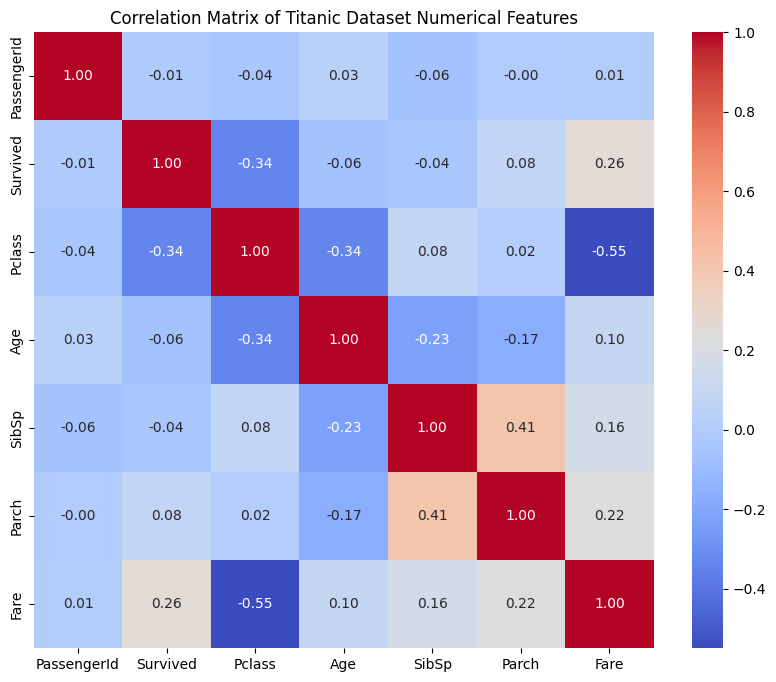

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Titanic Dataset Numerical Features')
plt.show()

## Visualize Survival Rates


## Summary:

### Data Analysis Key Findings

*   **Data Quality**: Missing values in the 'Age' column were imputed with the median (approximately 29.36 years), and missing 'Embarked' values were filled with the mode ('S'). The 'Cabin' column was dropped due to a high number of missing values. The dataset is now clean, with no missing values.
*   **Overall Survival Rate**: The overall survival rate in the dataset was approximately 38.38%.
*   **Demographic Overview**: The mean age of passengers was about 29.36 years. The most frequent gender was 'male', and the most common embarkation port was 'S'.
*   **Survival by Gender**: Females exhibited a significantly higher survival rate of approximately 74.2% compared to males, whose survival rate was approximately 18.9%.
*   **Survival by Passenger Class**: There was a clear correlation between passenger class and survival rate. 1st class passengers had the highest survival rate at approximately 63.0%, followed by 2nd class at approximately 47.3%, and 3rd class with the lowest survival rate at approximately 24.2%.
*   **Numerical Feature Correlations**: A correlation heatmap was generated to visualize the relationships between numerical features, such as 'PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', and 'Fare'.

### Insights

*   **Key Survival Factors**: Gender and passenger class were the most influential factors determining survival, indicating that social hierarchy and the "women and children first" protocol heavily impacted who survived the disaster.
*   **Advanced Predictive Modeling**: Further analysis could involve exploring interaction effects between 'Sex' and 'Pclass' and incorporating other features like 'Age' categories or 'Fare' ranges to build a more sophisticated predictive model for survival.


## Visualize Numerical Distributions


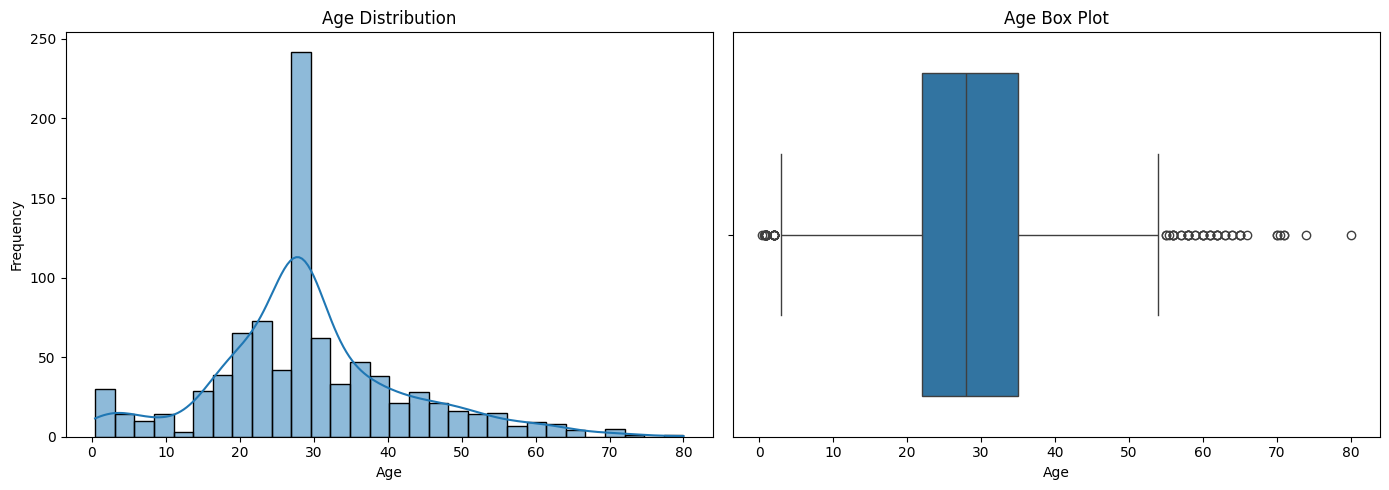

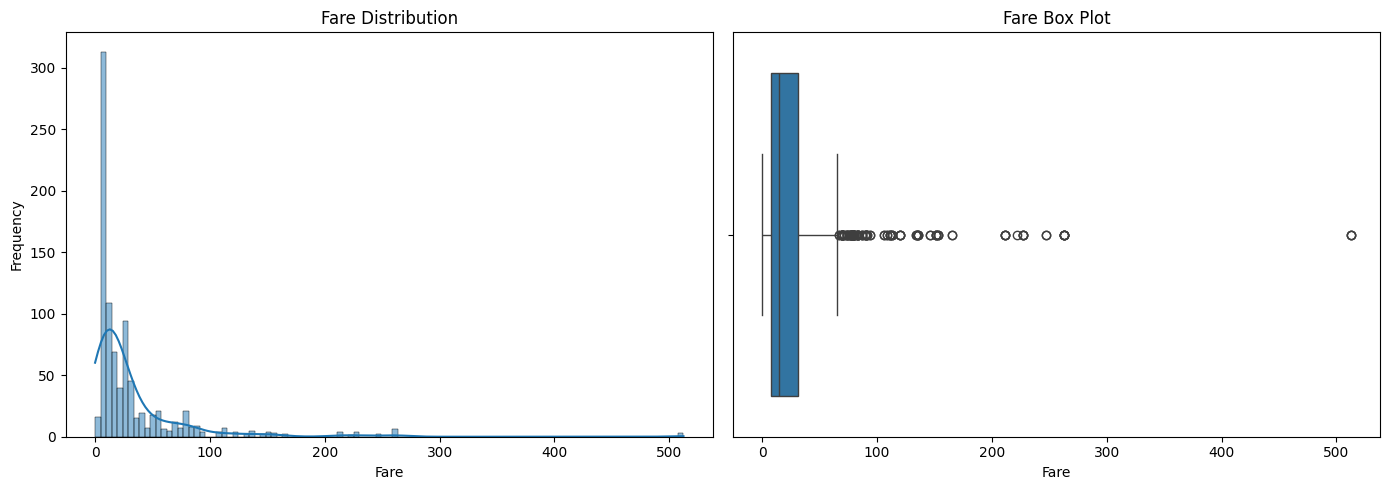

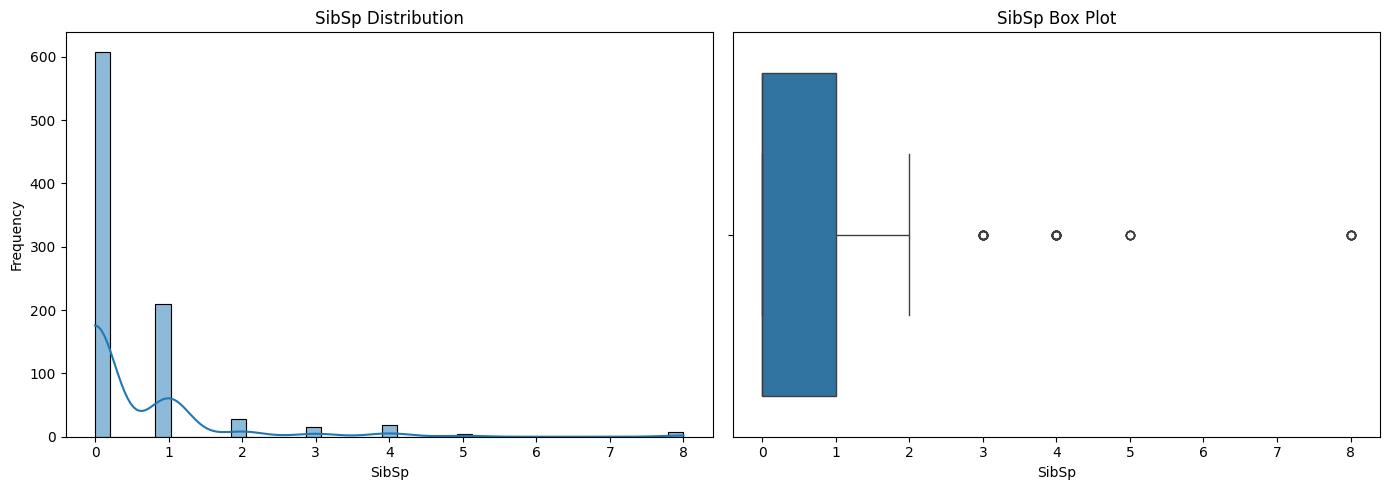

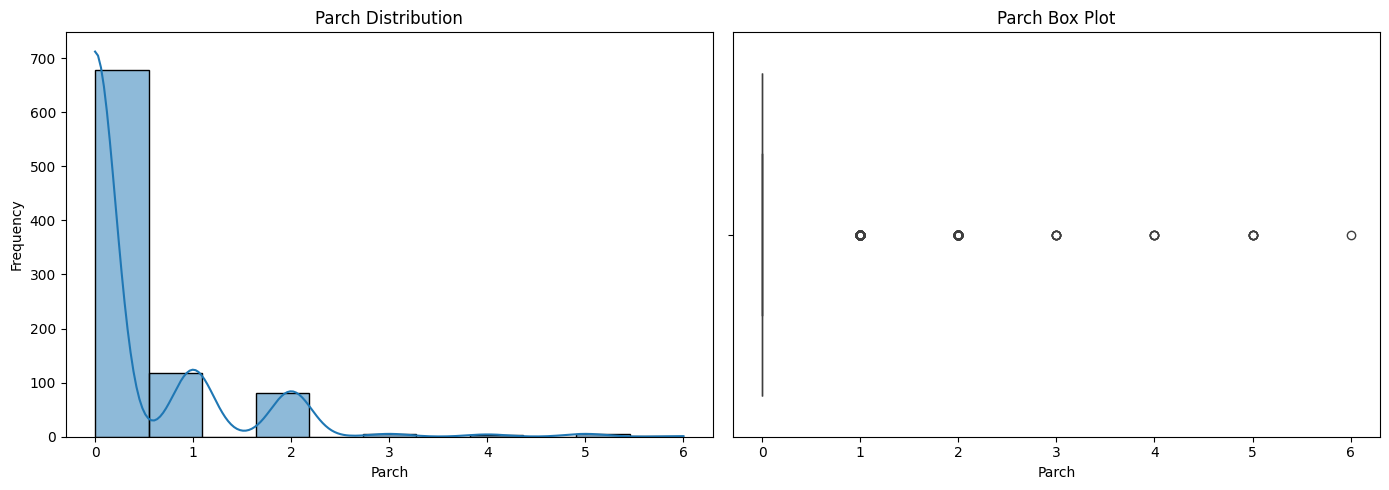

In [11]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box Plot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} Box Plot')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

### Summary of Numerical Distributions

*   **Age**: The age distribution is slightly right-skewed, with a peak around the late 20s. The box plot shows that the median age is around 28 years, consistent with the imputation strategy. There are several outliers, indicating a few older passengers.
*   **Fare**: The fare distribution is highly right-skewed, with most passengers paying lower fares and a few paying very high fares. The box plot clearly indicates a large number of outliers on the higher end, suggesting that most passengers paid inexpensive fares, while a small number paid significantly more.
*   **SibSp (Siblings/Spouses Aboard)**: The majority of passengers traveled alone (SibSp = 0). The distribution is heavily skewed towards zero, with a rapid decrease in counts for higher SibSp values. The box plot confirms that the median is 0, and there are outliers representing families with more siblings/spouses.
*   **Parch (Parents/Children Aboard)**: Similar to SibSp, most passengers traveled without parents or children (Parch = 0). The distribution is also heavily skewed towards zero. The box plot shows the median at 0, with outliers for passengers with more parents/children.

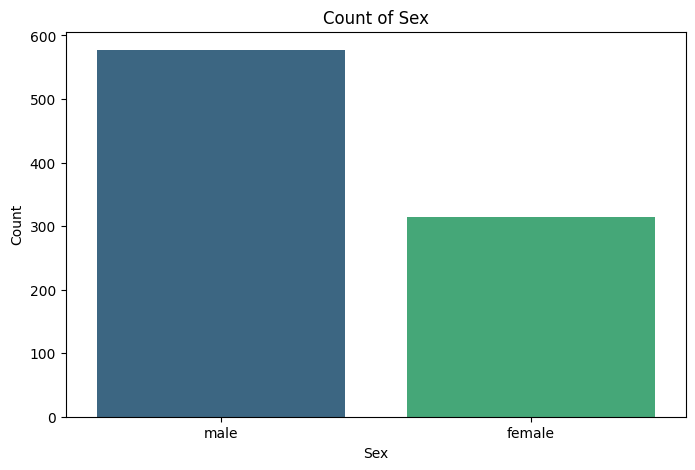

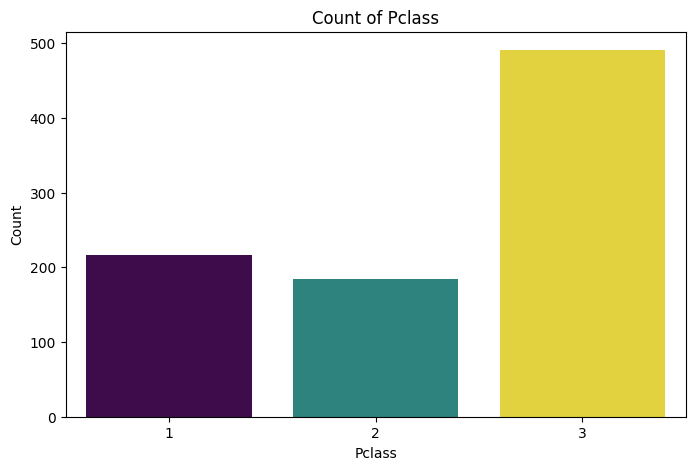

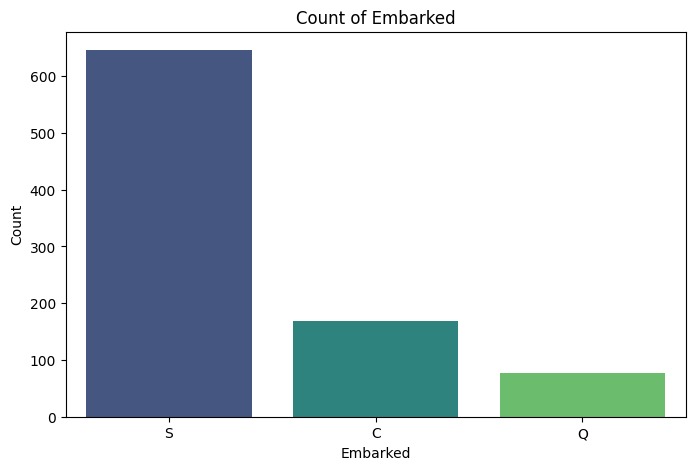

In [13]:
categorical_cols = ['Sex', 'Pclass', 'Embarked']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### Summary of Categorical Distributions

*   **Sex**: The dataset contains significantly more male passengers than female passengers, with approximately 577 males and 314 females.
*   **Pclass**: The majority of passengers were in 3rd class, followed by 1st class, and then 2nd class. This indicates an uneven distribution across socio-economic classes.
*   **Embarked**: The most common embarkation port was 'S' (Southampton), followed by 'C' (Cherbourg), and then 'Q' (Queenstown). This aligns with the mode imputation strategy used during data cleaning.

## Summary:

### Data Analysis Key Findings

*   **Age Distribution**: The age distribution is slightly right-skewed, with a peak around the late 20s and a median age of approximately 28 years. Outliers exist for older passengers.
*   **Fare Distribution**: The fare distribution is highly right-skewed, indicating that most passengers paid lower fares, while a significant number of outliers paid very high fares.
*   **SibSp and Parch Distributions**: Both 'SibSp' (siblings/spouses) and 'Parch' (parents/children) distributions are heavily skewed towards zero, meaning the majority of passengers traveled alone or without immediate family. Outliers represent larger family groups.
*   **Gender Distribution**: There are significantly more male passengers (approximately 577) than female passengers (approximately 314) in the dataset.
*   **Passenger Class Distribution**: The majority of passengers were in 3rd class, followed by 1st class, and then 2nd class, indicating an uneven socio-economic representation.
*   **Embarkation Port Distribution**: The most common embarkation port was 'S' (Southampton), followed by 'C' (Cherbourg), and then 'Q' (Queenstown).

### Insights

*   The highly skewed distributions of 'Fare', 'SibSp', and 'Parch' suggest that feature engineering (e.g., logarithmic transformation for 'Fare' or creating family size categories) might be beneficial for modeling.
*   The imbalance in gender and passenger class distributions highlights potential demographic biases that could influence survival rates, warranting further investigation into these relationships.


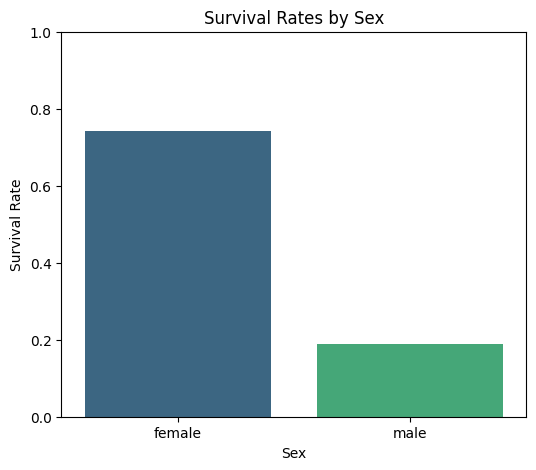

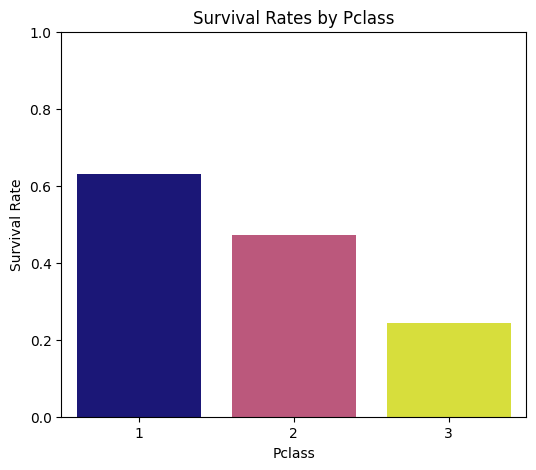

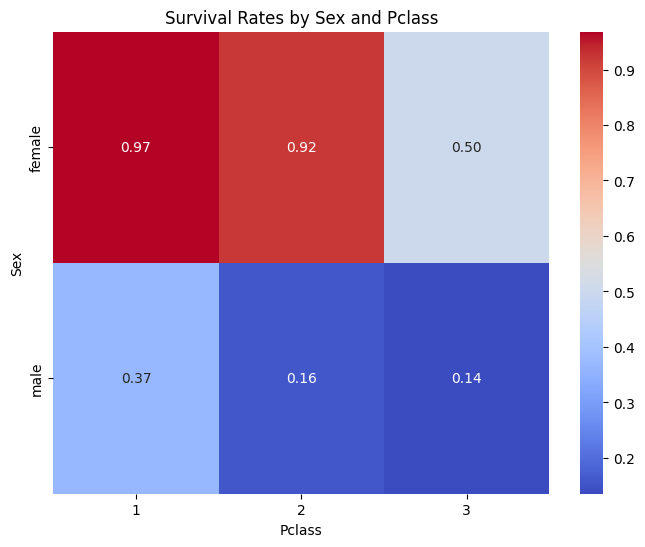

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot for Survival Rates by Sex
plt.figure(figsize=(6, 5))
sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, hue=survival_by_sex.index, palette='viridis', legend=False)
plt.title('Survival Rates by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

# Bar plot for Survival Rates by Pclass
plt.figure(figsize=(6, 5))
sns.barplot(x=survival_by_pclass.index, y=survival_by_pclass.values, hue=survival_by_pclass.index, palette='plasma', legend=False)
plt.title('Survival Rates by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

# Heatmap for Survival Rates by Sex and Pclass
survival_pivot = df.pivot_table(index='Sex', columns='Pclass', values='Survived')
plt.figure(figsize=(8, 6))
sns.heatmap(survival_pivot, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Survival Rates by Sex and Pclass')
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Age and Fare Distributions:** The majority of passengers were between 20 and 40 years old, with a right-skewed distribution. The `Fare` distribution was even more right-skewed, indicating that most passengers paid lower fares, while a few paid significantly higher amounts.
*   **Family Size:** Most passengers traveled alone or with very few family members (siblings/spouses and parents/children), as indicated by the highly skewed distributions of `SibSp` and `Parch`.
*   **Gender's Impact on Survival:** Females had a substantially higher survival rate compared to males across all passenger classes.
*   **Passenger Class and Survival:** First-class passengers exhibited the highest survival rate, followed by second-class, and then third-class, which had the lowest survival rate. This trend was also reflected in `Fare`, where higher fares correlated with higher survival rates.
*   **Age and Survival:** Children (especially those under 10) generally had better survival chances, aligning with the "women and children first" policy, though overall `Age` had a weak negative correlation with survival.
*   **Embarkation Port and Survival:** Passengers who embarked from Cherbourg (C) showed a relatively higher survival rate compared to those from Southampton (S) or Queenstown (Q).
*   **Correlation between Features:** A significant inverse relationship was observed between `Pclass` and `Fare` (lower Pclass number, higher fare). `Pclass` and `Sex` (when appropriately encoded) showed the strongest correlations with `Survived`, confirming their importance as predictive factors.

### Insights

*   The visual analysis strongly suggests that `Sex`, `Pclass`, and `Fare` are the most critical determinants of survival on the Titanic, highlighting socioeconomic status and gender as primary factors.
*   Further modeling efforts should prioritize these features and consider creating new features such as `FamilySize` (combining `SibSp` and `Parch`) or `IsAlone` to capture more nuanced relationships with survival.
